In [2]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
df = pd.read_csv("/content/complaints_processed.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (162421, 3)


,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


In [4]:
# Remove the unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

print("Dataset shape after removing index column:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nProduct categories:")
print(df["product"].value_counts())

Dataset shape after removing index column: (162421, 2)

Missing values:
product       0
narrative    10
dtype: int64

Duplicate rows:
37742

Product categories:
product
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64


In [5]:
# Remove rows with missing complaint narratives
df_clean = df.dropna(subset=["narrative"]).copy()

# Remove duplicate complaint narratives
df_clean = df_clean.drop_duplicates(subset=["narrative"]).copy()

# Reset the index
df_clean = df_clean.reset_index(drop=True)

print("Original dataset:", df.shape)
print("Cleaned dataset:", df_clean.shape)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

print("\nRemaining duplicate narratives:")
print(df_clean["narrative"].duplicated().sum())

Original dataset: (162421, 2)
Cleaned dataset: (124472, 2)

Missing values after cleaning:
product      0
narrative    0
dtype: int64

Remaining duplicate narratives:
0


## Exploratory Data Analysis

Product category distribution:
product
credit_reporting       56240
debt_collection        21057
mortgages_and_loans    18723
credit_card            14983
retail_banking         13469
Name: count, dtype: int64


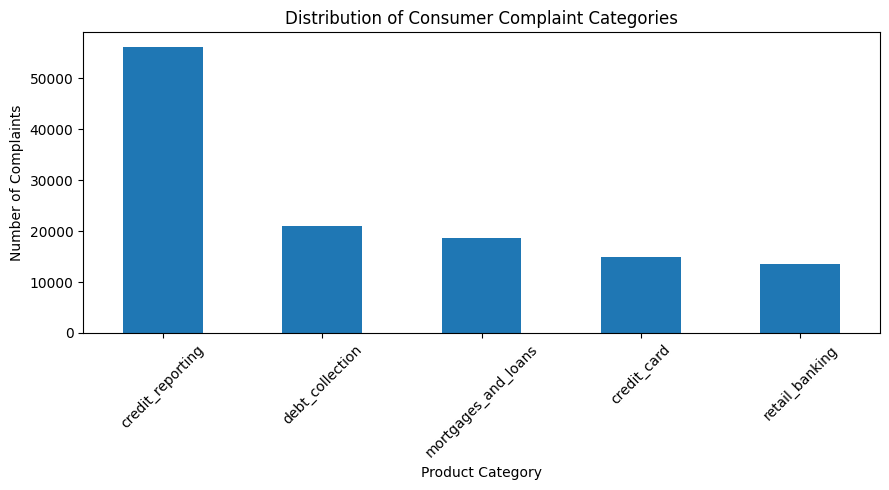

In [6]:
import matplotlib.pyplot as plt

category_counts = df_clean["product"].value_counts()

print("Product category distribution:")
print(category_counts)

category_counts.plot(kind="bar", figsize=(9, 5))

plt.title("Distribution of Consumer Complaint Categories")
plt.xlabel("Product Category")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Stratified Sampling

In [7]:
from sklearn.model_selection import train_test_split

# Create a reproducible stratified sample of 10,000 complaints
df_sample, _ = train_test_split(
    df_clean,
    train_size=10000,
    stratify=df_clean["product"],
    random_state=42
)

df_sample = df_sample.reset_index(drop=True)

print("Sample shape:", df_sample.shape)

print("\nProduct distribution in the sample:")
print(df_sample["product"].value_counts())

print("\nProduct percentages:")
print((df_sample["product"].value_counts(normalize=True) * 100).round(2))

Sample shape: (10000, 2)

Product distribution in the sample:
product
credit_reporting       4518
debt_collection        1692
mortgages_and_loans    1504
credit_card            1204
retail_banking         1082
Name: count, dtype: int64

Product percentages:
product
credit_reporting       45.18
debt_collection        16.92
mortgages_and_loans    15.04
credit_card            12.04
retail_banking         10.82
Name: proportion, dtype: float64


## Text Inspection

In [8]:
pd.set_option("display.max_colwidth", 200)

print("Example complaint narratives:")
display(
    df_sample[["product", "narrative"]]
    .sample(5, random_state=42)
)

# Calculate number of words in each complaint
df_sample["word_count"] = df_sample["narrative"].str.split().str.len()

print("\nComplaint length statistics:")
print(df_sample["word_count"].describe())

Example complaint narratives:


,product,narrative
6252,debt_collection,flagship credit acceptance adhere requested resent documentation giving opportunity cure invoice yet federally protected consumer flagship credit acceptance violated provision usc usc please revie...
4684,mortgages_and_loans,complaint address mr cooper letter dated response cfpb complaint abusive misconduct mortgage servicers seterus mr cooper toward homeowner including mismanagement surplus escrow fund see uploaded a...
1731,credit_card,problem barclay mastercard online account able get account online month spoken people time told would fixed day week day nothing wrong account nowhere near limit always pay minimum time told accou...
4742,retail_banking,dont underdtand happened going today tried login wouldnt let called said closed account fair reason ive always good customer never gave reason told surprised asked done didnt even tell horrible ex...
4521,retail_banking,bank america held check deposit day availability fund account holder combination seven account deposit auto settlement check need pay bill original insurance check cashed came bank america insuran...



Complaint length statistics:
count    10000.0000
mean        86.2526
std        113.1912
min          1.0000
25%         30.0000
50%         58.0000
75%        104.0000
max       2685.0000
Name: word_count, dtype: float64


## Preprocessing Verification

In [9]:
text_series = df_sample["narrative"].astype(str)

print("Rows containing uppercase letters:",
      text_series.str.contains(r"[A-Z]", regex=True).sum())

print("Rows containing numbers:",
      text_series.str.contains(r"\d", regex=True).sum())

print("Rows containing non-alphabetic characters:",
      text_series.str.contains(r"[^a-z\s]", regex=True).sum())

common_stopwords = [
    "the", "and", "is", "are", "a", "an", "to",
    "of", "in", "for", "this", "that", "with", "on", "it"
]

for word in common_stopwords:
    count = text_series.str.split().apply(lambda x: word in x).sum()
    print(f"{word}: {count}")

Rows containing uppercase letters: 0
Rows containing numbers: 0
Rows containing non-alphabetic characters: 0
the: 0
and: 0
is: 0
are: 0
a: 0
an: 5
to: 0
of: 0
in: 7
for: 0
this: 0
that: 0
with: 0
on: 0
it: 0


## Complaint Length Quality Check

In [10]:
print("Complaints with fewer than 5 words:",
      (df_sample["word_count"] < 5).sum())

print("Complaints with more than 500 words:",
      (df_sample["word_count"] > 500).sum())

print("\nShortest complaints:")
display(
    df_sample.sort_values("word_count")[["product", "narrative", "word_count"]].head(10)
)

Complaints with fewer than 5 words: 75
Complaints with more than 500 words: 89

Shortest complaints:


,product,narrative,word_count
5600,credit_reporting,approve,1
951,credit_reporting,inquires,1
5496,credit_reporting,inquire authorize,2
3191,debt_collection,received paperwork,2
1746,credit_reporting,remove inquiry,2
4535,credit_reporting,inquiry authorized,2
7783,credit_reporting,account removed,2
5573,retail_banking,transfer account,2
2994,debt_collection,billing idea,2
8876,credit_reporting,xxxxxxxx taking,2


In [11]:
print("Longest complaints:")

display(
    df_sample.sort_values(
        "word_count",
        ascending=False
    )[["product", "narrative", "word_count"]].head(5)
)

Longest complaints:


,product,narrative,word_count
6877,mortgages_and_loans,please refer full detail written within page pdf included better explain full length detail hi name wanted first thank time consideration care list valid complaint violation unrefutable proof supp...,2685
8932,debt_collection,dear cfpb please find follow complaint stole property money though chain fictitious intermediary posed lender fake servicer whose employee professionally lie federal authority defrauded homeowner ...,2325
243,credit_reporting,legal department credit dispute submitted new evidence dispute account disputed belong sworn statement concerning credit issue sworn statement declare penalty perjury law united state executed out...,2167
4045,debt_collection,ny social security dob texas ga pa disclosure identity theft dispute please refrain taking position identity theft either credit reporting agency subscribere partakes privlidges reporting consumer...,2076
319,debt_collection,cfpb complaint fraudulent year old heloc foreclosure complaint dear cfpb information easily verified documentation telephone recording relevant party please find relevant information document nece...,2017


## Final Dataset Preparation

Very short narratives containing fewer than five words were removed because they provide insufficient context for meaningful topic modelling. Long narratives were retained because inspection showed that they contain legitimate complaint information rather than obvious noise. A new stratified sample of 10,000 complaints was then created to preserve the original product-category proportions and ensure reproducibility.

In [12]:
# Calculate word counts for the full cleaned dataset
df_clean["word_count"] = df_clean["narrative"].str.split().str.len()

# Remove narratives with fewer than 5 words
df_filtered = df_clean[df_clean["word_count"] >= 5].copy()

print("Dataset before short-text filtering:", df_clean.shape)
print("Dataset after short-text filtering:", df_filtered.shape)

# Create the final reproducible stratified sample
df_final, _ = train_test_split(
    df_filtered,
    train_size=10000,
    stratify=df_filtered["product"],
    random_state=42
)

df_final = df_final.reset_index(drop=True)

print("\nFinal dataset shape:", df_final.shape)
print("\nFinal category distribution:")
print(df_final["product"].value_counts())

print("\nMinimum word count:", df_final["word_count"].min())
print("Maximum word count:", df_final["word_count"].max())

Dataset before short-text filtering: (124472, 3)
Dataset after short-text filtering: (123498, 3)

Final dataset shape: (10000, 3)

Final category distribution:
product
credit_reporting       4509
debt_collection        1692
mortgages_and_loans    1513
credit_card            1210
retail_banking         1076
Name: count, dtype: int64

Minimum word count: 5
Maximum word count: 1958


## Save Final Dataset

In [13]:
# Save the final dataset for use in the two topic-modelling pipelines
df_final.to_csv("/content/complaints_sample_10000.csv", index=False)

print("Final dataset saved successfully.")

Final dataset saved successfully.


## Preprocessing Summary

The original dataset contained 162,421 records. The unnecessary index column was removed, together with missing narratives and duplicate complaint texts. After cleaning, 124,472 unique complaints remained.

Exploratory analysis showed that the dataset is imbalanced across five product categories, with credit reporting representing the largest group. The supplied narratives were already heavily preprocessed: the text was lowercase, numbers and punctuation had been removed, and most common stop words were absent. Therefore, unnecessary repeated preprocessing was avoided.

Narratives shorter than five words were removed because they contained insufficient context for topic modelling. Longer narratives were retained after inspection because they contained legitimate complaint information. Finally, a reproducible stratified sample of 10,000 complaints was created using `random_state=42`. This sample preserves the original category proportions and will be used consistently in both topic-modelling pipelines.